# This Notebook gives a short example of a policy simulation 

It can be executed in the cloud with Google colab
## Run the notebook

To start, select:

**Google Colab:** Runtime → Run all  

The notebook may take a little time to finish starting.


To open  in colab press the button: 

<a href="https://colab.research.google.com/github/IbHansen/mfdemo/blob/main/Pakistan/PAK_CarbonTax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib Notebook

### This is code to manage dependencies if the notebook is executed in the google colab cloud service

In [2]:
# Only run installs on Colab
import importlib.util

if 'google.colab' in str(get_ipython()):
    if importlib.util.find_spec("modelclass") is None:
        !apt-get -qq install -y graphviz
        !pip -qq install ModelFlowIb > /dev/null 2>&1
        !mkdir -p data && curl -L https://raw.githubusercontent.com/worldbank/MFMod-ModelFlow/main/models/Pakistan/data/pak_new.pcim -o data/pak_new.pcim

## Now import ModelFlow

In [3]:
from modelclass import model

## Load the Pakistan model and run the baseline

In [19]:
mpak,bline = model.modelload('data/pak_new.pcim',run=True,keep='Baseline')

Zipped file read:  data\pak_new.pcim


## Simulating the impact of imposing a carbon price

To run a simulation, the following steps must invariably be followed.
1. Create a new DataFrame, typically a copy of an existing one.
2. Change the value in the new df of the variable(s) to be shocked.
3. Solve the model using the newly altered df as the input df.

## Simulating the impact of imposing a carbon price

A simulation follows three steps:

1. **Create a scenario DataFrame** from a baseline using `.upd()`, which applies an update expression that sets, scales, or grows selected variables over a chosen time range.
2. **Solve the model** by calling it with the scenario DataFrame, a start and end year, and a `keep=` label that names the scenario for later comparison.
3. **Inspect results** on the returned DataFrame or directly on the model, which stores each kept scenario.

### Create a scenario DataFrame*

Using the `.upd()` expression syntax

```
<start end>  VAR1 VAR2 ...  <op>  value
```

- **Time range** `<start end>` is optional; omit it to cover the full index.
- **Variables** are space-separated; wildcards (`*`, `?`) are supported.
- **Operators**: `=` (set), `+` (add), `*` (multiply), `%` (percent change),
  `=growth` / `+growth` (growth rate), `=diff` (difference).
  
Stacking more lines in the update string lets you shock several variables or time
ranges in one call.

## Example — a $30 nominal carbon tax on coal, gas, and oil, 2025–2050

In [5]:
CT30df = bline.upd("<2025 2050> PAKGGREVCO2CER PAKGGREVCO2GER PAKGGREVCO2OER = 30")

**Breakdown** 


$$
\begin{aligned}
&\underbrace{\texttt{CT30df}}_{\text{scenario df}}
 = \underbrace{\texttt{bline}}_{\text{baseline}}
 \,.\,\underbrace{\texttt{upd}}_{\text{accessor}}\bigl(\texttt{"}\ldots\texttt{"}\bigr) \\[8pt]
&\text{where the update string is} \\[4pt]
&\texttt{"}\,
 \overbrace{\texttt{<2025 2050>}}^{\text{years}}\ 
 \overbrace{\texttt{PAKGGREVCO2CER PAKGGREVCO2GER PAKGGREVCO2OER}}^{\text{coal, gas, oil CO}_2\text{ tax rates}}\ 
 \overbrace{\texttt{=}}^{\text{set}}\ 
 \overbrace{\texttt{30}}^{\text{USD/tCO}_2}
 \,\texttt{"}
\end{aligned}
$$

### Solve the model

In [20]:
resultsdf = mpak(CT30df,2020,2050,keep="Nominal $30USD Carbon tax")

**Breakdown**
$$
\small
\underbrace{\texttt{resultsdf}}_{\text{results df}}
= \underbrace{\texttt{mpak}}_{\text{model}}\bigl(
\underbrace{\texttt{CT30df}}_{\text{scenario df}},\;
\underbrace{\texttt{2020}}_{\text{start}},\;
\underbrace{\texttt{2050}}_{\text{end}},\;
\underbrace{\texttt{keep="Nominal \$30USD Carbon tax"}}_{\text{scenario label}}
\bigr)
$$

### Readable labels for the emission variables

To make tables and plots easier to read, we attach short descriptions to each emission variable and merge them into `mpak.var_description`. These labels can then be used instead of the raw codes wherever the model displays results.

In [7]:
var_descriptions = {
    'PAKCCEMISCO2CKN': 'Coal emissions, tCO2e',
    'PAKCCEMISCO2GKN': 'Natural Gas emissions, tCO2e',
    'PAKCCEMISCO2OKN': 'Crude Oil emissions, tCO2e',
    'PAKCCEMISCO2TKN': 'Total emissions, tCO2e',
}

mpak.var_description = mpak.var_description | var_descriptions

### Inspect results

 **Note**
 
 `resultsdf` is rarely used directly. The model object `mpak` keeps the baseline (`mpak.basedf`) and the latest run (`mpak.lastdf`) internally, so the following cells can compare and plot results directly from `mpak`.

In [10]:
mpak['PAKNYGDPMKTPCN PAKFMLBLPOLYXN PAKCCEMISCO2?KN']

In [18]:
mpak.modeldash('PAKNYGDPMKTPCN')

Dash app running on http://127.0.0.1:5001/


In [17]:
mpak['PAKNYGDPMKTPCN PAKFMLBLPOLYXN PAKCCEMISCO2?KN'].rplot(samefig=1,datatype='difpctlevel')

Accordion(children=(HTML(value='<?xml version="1.0" encoding="utf-8" standalone="no"?>\n<!DOCTYPE svg PUBLIC "…

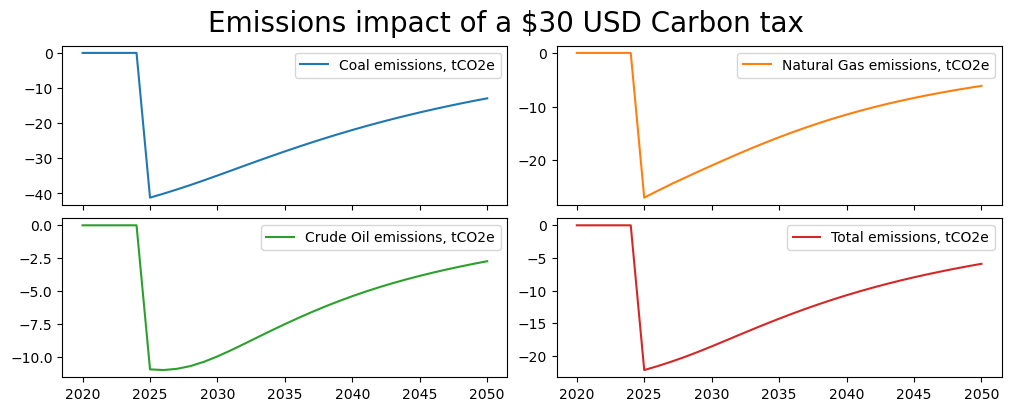

In [9]:
mpak['PAKCCEMISCO2?KN'].difpctlevel.rename().plot(title="Emissions impact of a $30 USD Carbon tax");

**Breakdown**

| Element | What it does |
|:---|---|
| `mpak` | The model object holding the baseline and the latest simulation |
| `['PAKCCEMISCO2*']` | Select all variables matching the pattern — here, CO₂ emissions |
| `.difpctlevel` | Percent difference between the latest simulation and the baseline |
| `.rename()` | Use the variable descriptions |
| `.df` | Return the underlying pandas DataFrame (rows = years, columns = variables) |
| `.T` | Transpose so variables become rows and years become columns |
| `.style.format("{:.2f}")` | Render as a styled table with values shown to two decimal places |